In [1]:
import pandas as pd


df = pd.read_csv("popularBooksList.csv")

print(df.head(10).to_markdown(index=False))

| Title                                        | Author              | In A Series   |   Pages |   Year | Genres/Tags                                                                                            |   Rating |
|:---------------------------------------------|:--------------------|:--------------|--------:|-------:|:-------------------------------------------------------------------------------------------------------|---------:|
| Project Hail MaryAndy Weir                   | Andy Weir           | False         |     476 |   2021 | ['funny', 'adventurous', 'hopeful', 'science fiction', 'fiction', 'medium-paced']                      |     4.5  |
| In Her Own LeagueLiz Tomforde                | Liz Tomforde        | True          |     440 |   2026 | ['sports', 'emotional', 'romance', 'lighthearted', 'funny', 'fiction', 'medium-paced', 'contemporary'] |     4.47 |
| This Story Might Save Your LifeTiffany Crum  | Tiffany Crum        | False         |     368 |   2026 | ['emot

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure rating is numeric
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

# Split data
standalone = df[df["In A Series"] == False]
series = df[df["In A Series"] == True]

# Get best books
best_standalone = standalone.loc[standalone["Rating"].idxmax()]
best_series = series.loc[series["Rating"].idxmax()]

print("Best Standalone Book:")
print(best_standalone[["Title", "Rating"]])

print("\nBest Series Book:")
print(best_series[["Title", "Rating"]])

Best Standalone Book:
Title     One Day, Everyone Will Have Always Been Agains...
Rating                                                 4.69
Name: 60, dtype: object

Best Series Book:
Title     The Way of KingsBrandon Sanderson
Rating                                 4.63
Name: 206, dtype: object


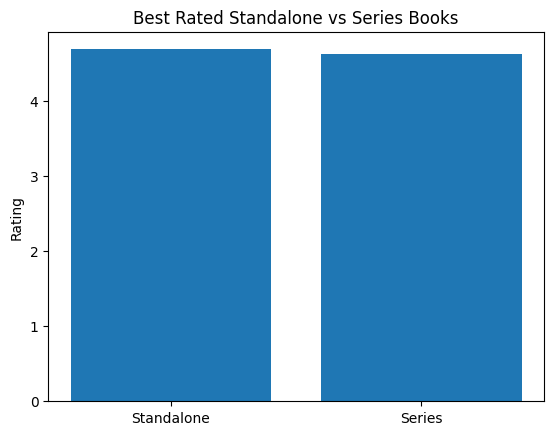

In [ ]:
labels = ["Standalone", "Series"]
ratings = [best_standalone["Rating"], best_series["Rating"]]

plt.figure()
plt.bar(labels, ratings)
plt.ylabel("Rating")
plt.title("Best Rated Standalone vs Series Books")

#plt.savefig("best_books_comparison.png")
plt.show()

In [22]:
import ast

def ensure_list(x):
    if isinstance(x, list):
        return x
    elif isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return [x]
    else:
        return [x]

df["Genres/Tags"] = df["Genres/Tags"].apply(ensure_list)


# Explode genres into separate rows
df_exploded = df.explode("Genres/Tags")

# Remove missing values
df_exploded = df_exploded.dropna(subset=["Genres/Tags", "Rating"])

# Compute average rating per genre
genre_ratings = (
    df_exploded
    .groupby("Genres/Tags")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

# Take top 10 genres
top_genres = genre_ratings.head(10)

bottom_genres = genre_ratings.tail(10)

bottom_genres

Genres/Tags
slow-paced         4.087273
classics           4.083684
contemporary       4.082708
mystery            4.078000
sports             4.048889
crime              4.033333
lighthearted       4.027727
thriller           4.025769
magical realism    3.947500
horror             3.932308
Name: Rating, dtype: float64

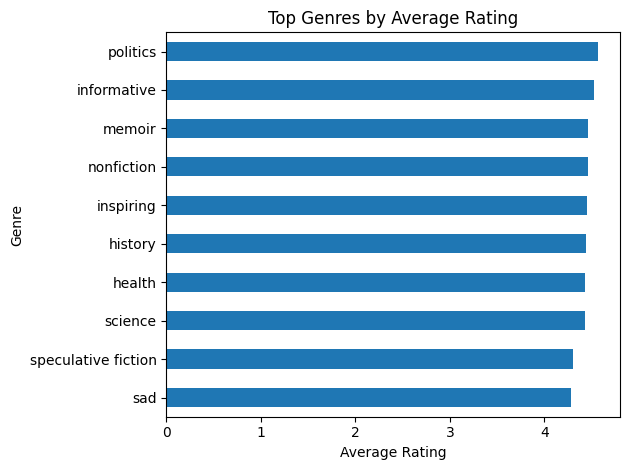

In [27]:
top_genres.plot(kind="barh")
plt.xlabel("Average Rating")
plt.ylabel("Genre")
plt.title("Top Genres by Average Rating")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig("top_genres.png", bbox_inches="tight")
plt.show()
plt.show()

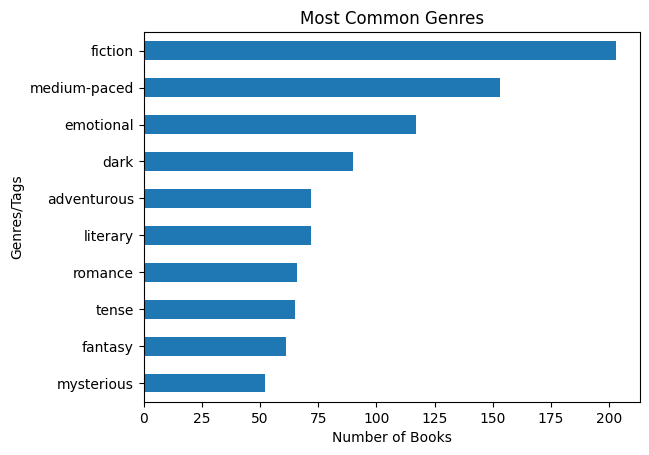

In [17]:
genre_counts = df.explode("Genres/Tags")["Genres/Tags"].value_counts().head(10)

genre_counts.plot(kind="barh")

plt.xlabel("Number of Books")
plt.title("Most Common Genres")

plt.gca().invert_yaxis()
plt.savefig("genre_counts.png")
plt.show()

<Figure size 640x480 with 0 Axes>

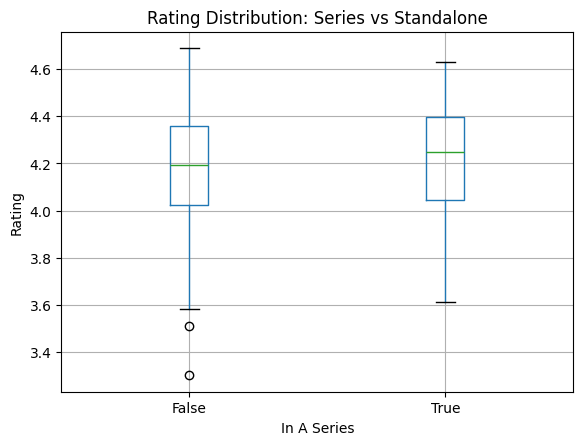

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

df.boxplot(column="Rating", by="In A Series")

plt.title("Rating Distribution: Series vs Standalone")
plt.suptitle("")  
plt.xlabel("In A Series")
plt.ylabel("Rating")

plt.savefig("series_vs_standalone_boxplot.png")
plt.show()

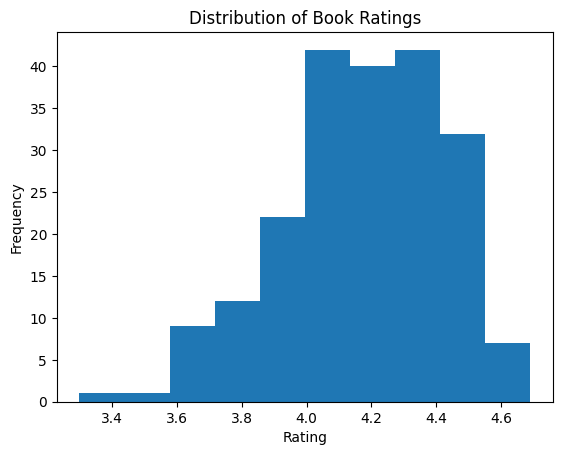

In [21]:
plt.figure()
df["Rating"].dropna().plot(kind="hist", bins=10)

plt.xlabel("Rating")
plt.title("Distribution of Book Ratings")

plt.savefig("rating_distribution.png")
plt.show()

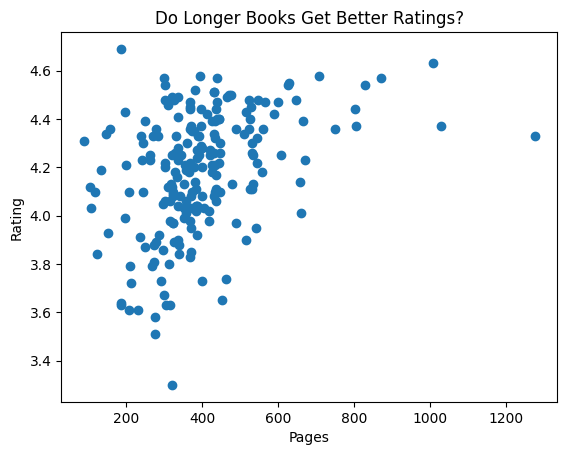

In [20]:
plt.figure()
plt.scatter(df["Pages"], df["Rating"])

plt.xlabel("Pages")
plt.ylabel("Rating")
plt.title("Do Longer Books Get Better Ratings?")

#plt.savefig("pages_vs_rating.png")
plt.show()

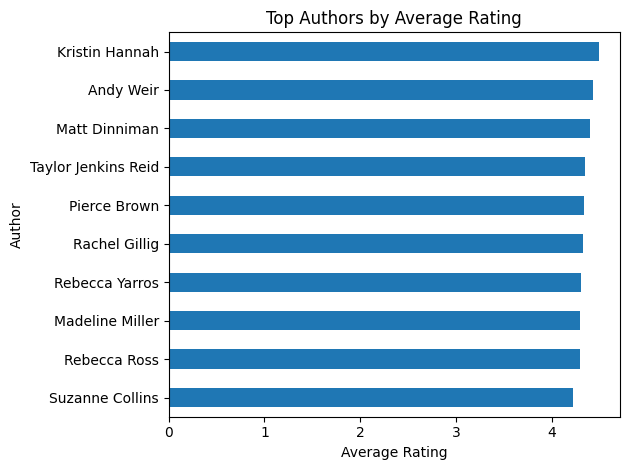

In [26]:
author_counts = df["Author"].value_counts()

valid_authors = author_counts[author_counts >= 2].index

author_ratings = (
    df[df["Author"].isin(valid_authors)]
    .dropna(subset=["Rating"])
    .groupby("Author")["Rating"]
    .mean()
    .sort_values(ascending=False)
)
top_authors = author_ratings.head(10)

top_authors.plot(kind="barh")

plt.xlabel("Average Rating")
plt.ylabel("Author")
plt.title("Top Authors by Average Rating")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig("top_authors.png", bbox_inches="tight")
plt.show()
plt.show()